# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** Nurul Amanda
- **Email:** svsf36@gmail.com
- **ID Dicoding:** CDCC326D6X2670

## Menentukan Pertanyaan Bisnis

- Kategori produk manakah yang menjadi primadona (paling laris dan memberikan pendapatan tertinggi) selama periode 2016-2018, dan bagaimana strategi yang tepat untuk masing-masing kategori tersebut?

- Bagaimana tren pertumbuhan penjualan bulanan dari tahun 2016 hingga 2018, serta di wilayah (negara bagian) mana saja yang memiliki potensi pasar tertinggi untuk menjadi fokus ekspansi bisnis ke depannya?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import MarkerCluster
import geopandas as gpd

from datetime import datetime

plt.style.use('ggplot')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

## Data Wrangling

### Gathering Data

In [2]:
df_customers = pd.read_csv('customers_dataset.csv')
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
df_geolocation = pd.read_csv('geolocation_dataset.csv')
df_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [4]:
df_order_items = pd.read_csv('order_items_dataset.csv')
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
df_order_payments = pd.read_csv('order_payments_dataset.csv')
df_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
df_order_reviews = pd.read_csv('order_reviews_dataset.csv')
df_order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [7]:
df_orders = pd.read_csv('orders_dataset.csv')
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
df_products = pd.read_csv('products_dataset.csv')
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [9]:
df_sellers = pd.read_csv('sellers_dataset.csv')
df_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [10]:
df_category_translation = pd.read_csv('product_category_name_translation.csv')
df_category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight :**

1.   **Customer Dataset :**  

*   Dataset berisi data pelanggan dengan `customer_id` sebagai identifer unik untuk setiap transaksi
*   `customer_unique_id` memungkinkan 1 pelanggan memiliki beberapa transaksi (repeat order)
*   Berdasarkan sampel 5 data pertama, **100% pelanggan berasal dari negara bagian SP (Sao Paulo)**
*   Kota-kota seperti Franca, Campinas, dan Sao Paulo mendominasi sebagai lokasi pelanggan

2.   **Geolocation Dataset :**
*   Dataset menyediakan koordinat georafis (latitude & longitude) berdasarkan kode pos
*   **1 kode pos bosa memiliki beberapa titik kordinat berbeda,** contohnya kode pos 1046 memiliki 2 koordinat berbeda di kota Sao Paulo.
*   Data geolocation didominasi oleh wilayah **SP (Sao Paulo)** dari sample yang ditampilkan
*   Dataset ini sangat berguna untuk analisis spasial dan visualisasi peta

3. **Order Items Dataset :**
*   Setiap order bisa memiliki beberapa item yang ditandai dengan `order_item_id`
*   Dari sample, setiap order hanya berisi 1 item (order_item_id = 1 untuk semua sample)
*   Harga produk bervariasi dari ** 12.99 hingga 239.90**
*   Harga produk bervariasi dari ** 12.99 hingga 239.90**
*   Biaya pengiriman (freight_value) berkisar antara **12.79 hingga 19.3 **
*   Dataset menghubungkan order dengan produk dan seller

4. **Order Payments Dataset :**
*   Metode pembayaran dominan adalah **credit card** (100% dari sample menggunakan credit card)
*   Cicilan pembayaran bervariasai: ada yang **1x, 2x, dan 8x cicilan**
*   Nilai pembayaran berkisar dari **24.39 hingga 128.45**
*   `payment_sequential` menunjukkan bahwa pembayaran bisa dilakakan bertahap (semua sample masih bernilai 1 )

5. **Order Reviews Dataset :**
*   **Skor review tinggi (4-5)** mendominasi dari sample data
*   Kolom `review_comment_title` dan `review_comment_message` **banyak mengandung NaN (missing values)**
*   Meskipun banyak komentar kosong, pelanggan tetap memberikan skor tinggi
*   Ada contoh komentar positif: *"Recebi bem antes do prazo estipulado dan Parabens..."* (brang datang lebih cepat dari estimasi)
*   Dataset mencatat waktu pembuatan review dan waktu jawaban review

6. **Orders Dataset :**
*   **Semua order berstatus "delivered"** (terkirim) dari sample yang ditampilkan
*   Terdapat beberapa timestamp penting: purchase, approved, delived by carrier, delived to customer
*   Dari sample, **pengiriman cenderung lebih cepat dari estimasi**, contoh: order dibeli 2 Oktober 2017, terkirim 10 Oktober 2017, estimasi 18 Oktober 2017 (8 hari lebih cepat)
*   Dataset ini adalah tabel utama yang menghubungkan customer dengan transaksi

7. **Products Dataset :**
*   Produk memiliki berbagai kategor seperti **perfumaria, artes, esporte_lazer, bebes, dan utilidades_domesticas**
*   Panjang nama produk bervariasi antara **27-46 karakter**
*   Panjang deskripsi produk antara **250-402 karakter**
*   Jumlah foto produk: **1-4 foto** per produk
*   Berat produk bervariasi dari **154 gram hingga 1000 gram**
*   Dimensi produk (panjang x lebar x tinggi) bervariasai sesuai kategori

8. **Sellers Dataset :**
*   Dataset berisi data penjual dengan `seller_id` unik
*   Dari 5 sample seller, **4 berasal dari SP (Sao Paulo)** dan **1 dari RJ (Rio de janeiro)**
*   Kota asal seller: Campinas, Mogi Guacu, Rio de Janeiro, Braganca Paulista
*   **Konsentrasi penjual terpusat di wilayah Sao Paulo,** menunjukkan pusat e-commerce Brasil

9. **Product Category Translation Dataset :**
*   Dataset menyediakan **terjemahan kategori produk dari Bahasa Portugis ke Bahasa Inggris**
*   Contoh terjemahan: *Beleza_saude* = **health_beauty** (kecantikan & kesehatan) DLL
*   Dataset ini pentinh untuk mengubah label kategori agar lebih mudah dipahami dalam analisis



















### Assessing Data

In [11]:
# 1. Customers Dataset
df_customers.info()
df_customers.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [12]:
print("Jumlah duplikasi: ", df_customers.duplicated().sum())
df_customers.describe()

Jumlah duplikasi:  0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [13]:
# 2. Geolocation Dataset
df_geolocation.info()
df_geolocation.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [14]:
print("Jumlah duplikasi: ", df_geolocation.duplicated().sum())
df_geolocation.describe()

Jumlah duplikasi:  261831


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [15]:
# 3. Order Items Dataset
df_order_items.info()
df_order_items.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [16]:
print("Jumlah duplikasi: ", df_order_items.duplicated().sum())
df_order_items.describe()

Jumlah duplikasi:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [17]:
# 4. Order Payments Dataset
df_order_payments.info()
df_order_payments.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [18]:
print("Jumlah duplikasi: ", df_order_payments.duplicated().sum())
df_order_payments.describe()

Jumlah duplikasi:  0


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [19]:
# 5. Order Reviews Dataset
df_order_reviews.info()
df_order_reviews.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [20]:
print("Jumlah duplikasi: ", df_order_reviews.duplicated().sum())
df_order_reviews.describe()

Jumlah duplikasi:  0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [21]:
# 6. Order Dataset
df_orders.info()
df_orders.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [22]:
print("Jumlah duplikasi: ", df_orders.duplicated().sum())

df_orders.describe()

Jumlah duplikasi:  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [23]:
# 7.Products Dataset
df_products.info()
df_products.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [24]:
print("Jumlah duplikasi: ", df_products.duplicated().sum())

df_products.describe()

Jumlah duplikasi:  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [25]:
# 8. Sellers Dataset
df_sellers.info()
df_sellers.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [26]:
print("Jumlah duplikasi: ", df_sellers.duplicated().sum())
df_sellers.describe()

Jumlah duplikasi:  0


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [27]:
# 9.Product Category Translation Dataset
df_category_translation.info()
df_category_translation.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,0
product_category_name,0
product_category_name_english,0


In [28]:
print("Jumlah duplikasi: ", df_category_translation.duplicated().sum())
df_category_translation.describe()

Jumlah duplikasi:  0


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


**Insight:**
1.   **Customers Dataset :** Dataset pelanggan bersih, tidak ada miising value atau duplikasi. Kode pos (zip code) pelanggan bervariasi dari **1003 hingga 99990**, menunjukkan cakupan area yang luas di Brazil.

2.   **Geolocation Dataset :** Dataset ini memiliki masalah kualitas data yang signifikan dengan **249.378 baris duplikat (sekitar 26.5 % dari total data).** Selain itu ditemukan 1 nilai yang hilang di kolom `geolocation_city` dan `geolocation_state`.

3.   **Order Items Dataset :** Data item pesanan lengkap tanpa missing value atau duplikasi. Sebuah pesanan bisa berisi hinngga 21 item yang berbeda (maks `order_item_id` = 21). Biaya pengiriman (freight value) bervariasi besar, dengan nilai maksimum mencapai 112650.0

4.   **Order Payments Dataset :** Data pembayaran bersih tanpa missing value atau duplikasi. Sebuah pesanan bisa dibayar hingga 29 kali cicilan (`payment_sequential` maks 29) dengan jumlah cicilan sebanyak 24 kali (`payment_installments` maks 24) dan ada transaksi dengan nilai pembayaran 0.0

5.   **Order Reviews Dataset :** Sebagian besar ulasan tidak memberikan komentar tertulis,terlihat dari banyaknya missing value pada kolom `review_comment_title` (87.656 missing value) dan `review_comment_message`	(58247 misiing value). Namun, skor ulasan cenderung sangat positif dengan rata-rata 4.08 sampai 5.0.

6.   **Orders Dataset :** Terdapat missing value pada timestamp pesanan, terutama pada `order_delivered_customer_date `(2.965 missing value) yang kemungkinan besar menandakan pesanan belum sampai ke pelanggan. Setiap pelanggan (*customer_id*) bersifat unik, mengindikasikan tidak ada pelanggan yang melakukkan pemesanan lebih dari sekali dalam dataset ini.

7.   **Products Dataset :** Ada missing value pada data produk, terutama 610 produk (tanpa kategori, nama, deskripsi, atau jumlah foto). Selain itu, ada 2 produk yang tidak memiliki informasi dimensi dan benar serta tidak ada duplikasi data produk.

8.   **Sellers Dataset :** Data penjual bersih, tidak ada missing value atau duplikiasi. Kode pos penjual juga bervariasi, mengindikasikan sebaran penjual yang luas.

9. **Product Category Translation Dataset :** Dataset ini bersih dan lengkap dan berhasil memetakan 71 kategori unik produk dari bahasa Portugis ke bahasa Inggris.







### Cleaning Data

In [29]:
# 1. Customers Dataset
# Tidak perlu cleaning karena tidak ada missing vales dan duplikasi
df_customers_clean = df_customers.copy()
print("Customers Dataset: Data sudah bersih")

Customers Dataset: Data sudah bersih


In [30]:
# 2. Geolocation Dataset
# Menghapus duplikasi (249.378 baris duplikasi)
df_geolocation_clean = df_geolocation.drop_duplicates()
print("Jumlah duplikasi: ", df_geolocation.duplicated().sum())

# Mengatasai missing value di geolocation_city dan geolocation_state
df_geolocation_clean = df_geolocation_clean.dropna(subset=['geolocation_city', 'geolocation_state'])
df_geolocation_clean.isna().sum()

Jumlah duplikasi:  261831


,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [31]:
# 3. Order Items Dataset
# Tidak perlu cleaning karena tidak ada missing vales dan duplikasi
df_order_items_clean = df_order_items.copy()
print("Order Items Dataset: Data sudah bersih")

Order Items Dataset: Data sudah bersih


In [32]:
# 4. Order Payment Dataset
# Tidak perlu cleaning karena tidak ada missing vales dan duplikasi
df_order_payemnts_clean = df_order_payments.copy()
print("Order Payment Dataset: Data sudah bersih")

Order Payment Dataset: Data sudah bersih


In [33]:
# 5. Order Reviews Dataset
# Missing values pada kolom komentar tidak perlu dihapus karena wajar
# tapi kita bisa isi dengan placeholder jika diperlukan
df_order_reviews_clean = df_order_reviews.copy()
df_order_reviews_clean['review_comment_title'] = df_order_reviews_clean['review_comment_title'].fillna('no_comment')
df_order_reviews_clean['review_comment_message'] = df_order_reviews_clean['review_comment_message'].fillna('no_comment')
print(f"Reviews - missing title diisi dengan 'no_comment': {df_order_reviews_clean['review_comment_title'].isna().sum()}")
print(f"Reviews - missing message diisi dengan 'no_comment': {df_order_reviews_clean['review_comment_message'].isna().sum()}")

Reviews - missing title diisi dengan 'no_comment': 0
Reviews - missing message diisi dengan 'no_comment': 0


In [34]:
# 6. Order Dataset
# Menangani missing value
df_orders_clean = df_orders.dropna(subset=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'])
df_orders_clean.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


In [35]:
# 7. Products Dataset
# Menangani missing value
df_products_clean = df_products.dropna(subset=['product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'])
df_products_clean.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [36]:
# 8. Sellers Dataset
# Tidak perlu cleaning karena tidak ada missing values dan duplikasi
df_sellers_clean = df_sellers.copy()
print("Sellers Dataset: Data sudah bersih")

Sellers Dataset: Data sudah bersih


In [37]:
# 9. Product Category Translation Dataset
# Tidak perlu cleaning karena tidak ada missing values dan duplikasi
df_category_translation_clean = df_category_translation.copy()
print("Category Translation Dataset: Data sudah bersih")

Category Translation Dataset: Data sudah bersih


**Insight:**

1.   **Customers Dataset :**  
*   Tidak ditemukan missing values atau duplikasi, data sudah bersih dan siap digunakan.

2.   **Geolocation Dataset :**

*   Berhasil menghapus 261.831 baris duplikat (sekitar 26% dari total data).
*  Missing values pada kolom city dan state telah diatasi dengan menghapus baris yang bermasalah.
*  Dataset geolocation kini lebih efisien untuk analisis spasial.

3.   **Order Items Datase :**

*   Data item pesanan sudah bersih tanpa missing values atau duplikasi.
*   Siap digunakan untuk analisis produk dan harga.

4.   **Order Payments Dataset :**

*   Data pembayaran sudah bersih tanpa missing values atau duplikasi.
*   Siap digunakan untuk analisis metode pembayran dan nilai transaksi

5.   **Order Reviews Dataset :**

*   Missing values pada kolom komentar (87.656 judul dan 58.247 pesan) diisi dengan placeholder 'no_comment'.
*   Skor review tetap terjaga meskipun banyak pelanggan tidak memberikan komentar tertulis.

6.   **Orders Dataset :**
*   160 baris dengan missing order_approved_at telah dihapus karena tidak valid untuk analisis (pembayaran tidak terverifikasi)
*   Setelah pembersihan, semua kolom sudah tidak memiliki missing value (nilai 0 untuk semua kolom), termasuk `order_delivered_carrier_data` dan `order_delivered_customer_date`.
*   Jumlah data berkurang dari **99.441 menjadi 99.281 baris** setelah pembersihan (hanya kehilangan 160 baris).
*   Dataset orders kini bersih dan siap digunakan untuk analisis lebih lanjut.

7.   **Products Dataset :**
*   610 produk dengan missing values pada kategori, nama, dan deskripsi telah dibersihkan.
*   2 produk dengan missing dimensi juga telah ditangani.
*   Dataset produk kini memiliki informasi lengkap untuk semua produk.

8.   **Sellers Dataset :**
*   Data penjual sudah bersih tanpa missing values atau duplikasi.
*   Siap digunakan untuk analisis seller dan geografis.

9.   **Product Category Translation Dataset :**
*   Data terjemahan kategori sudah bersih dan lengkap dengan 71 kategori unik.
*   Siap digunakan untuk menerjemahkan kategori produk dari Bahasa Portugis ke Inggris.


## Exploratory Data Analysis (EDA)

### Explorasai Data df_customers

In [38]:
# 1.Rangkuman statistik customers_df
df_customers.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [39]:
# 2. Demografi pelanggan berdasarkan negara bagian (state)
customer_by_state = df_customers.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)
display(customer_by_state)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


In [40]:
# 3. Demografi pelanggan berdasarkan kota
customer_by_city = df_customers.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)
display(customer_by_city)

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
agisse,1
vieiras,1
bertopolis,1


### Explorasai Data df_orders

In [41]:
# Rangkuman statistik df_orders

df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

# Hitung waktu pengiriman (dalam hari)
delivery_time = df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']
df_orders['delivery_time_days'] = delivery_time.dt.days

display(df_orders['delivery_time_days'].describe())

,delivery_time_days
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [42]:
# 2. Status pesanan
order_status = df_orders['order_status'].value_counts()
display(order_status)

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [43]:
# 1. Rangkuman statistik products_df

df_orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days
count,99441,99441,99441,99441,99281,97658,96476,99441,96476.000000
unique,99441,99441,8,NaN,90733,81018,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,2018-02-27 04:31:10,2018-05-09 15:48:00,NaN,NaN,NaN
freq,1,1,96478,NaN,9,47,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,NaN,NaN,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,12.094086
min,NaN,NaN,NaN,2016-09-04 21:15:19,NaN,NaN,2016-10-11 13:46:32,2016-09-30 00:00:00,0.000000
25%,NaN,NaN,NaN,2017-09-12 14:46:19,NaN,NaN,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,6.000000
50%,NaN,NaN,NaN,2018-01-18 23:04:36,NaN,NaN,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,10.000000
75%,NaN,NaN,NaN,2018-05-04 15:42:16,NaN,NaN,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,15.000000
max,NaN,NaN,NaN,2018-10-17 17:30:18,NaN,NaN,2018-10-17 13:22:46,2018-11-12 00:00:00,209.000000


### Explorasai Data df_product

In [44]:
# 1. Ranngkuman statistik df_procuct
df_products.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [45]:
# 2. Kategori produk
product_by_category = df_products['product_category_name'].value_counts().head(15)
display(product_by_category)

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


In [46]:
# 3. Produl dengan harga termahal dan termurah (setelah merge dengan orders_items)
# Perlu merge products dengan order_items untuk melihat harga

product_prices = df_order_items.groupby(by='product_id')['price'].mean().reset_index()
product_prices = product_prices.merge(df_products[['product_id', 'product_category_name']], on='product_id', how='left')
df_customers.describe(include="all")

print("\n--- 5 Produk Termahal ---")
top_expensive = product_prices.sort_values('price', ascending=False).head(5)
display(top_expensive)

print("\n --- 5 Produk Termurah ---")
top_cheapest = product_prices.sort_values('price', ascending=True).head(5)
display(top_cheapest)


--- 5 Produk Termahal ---


,product_id,price,product_category_name
9434,489ae2aa008f021502940f251d4cce7f,6735.0,utilidades_domesticas
13693,69c590f7ffc7bf8db97190b6cb6ed62e,6729.0,pcs
3698,1bdf5e6731585cf01aa8169c7028d6ad,6499.0,artes
21316,a6492cc69376c469ab6f61d8f44de961,4799.0,eletroportateis
25197,c3ed642d592594bb648ff4a04cee2747,4690.0,eletroportateis



 --- 5 Produk Termurah ---


,product_id,price,product_category_name
17767,8a3254bee785a526d548a81a9bc3c9be,0.85,construcao_ferramentas_construcao
5158,270516a3f41dc035aa87d220228f844c,1.20,beleza_saude
700,05b515fdc76e888aada3c6d66c201dff,1.20,beleza_saude
9238,46fce52cef5caa7cc225a5531c946c8b,2.20,beleza_saude
6388,310dc32058903b6416c71faff132df9e,2.29,papelaria


### Eksplorasi Data Gabungan (df_orders + df_customers)

In [47]:
# Merge orders dengan customers
orders_customers_df = pd.merge(
    left=df_orders_clean,
    right=df_customers,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

display(orders_customers_df.head())

# 1. Jumlah order berdasarkan negara bagian

order_by_state = orders_customers_df.groupby(by="customer_state").order_id.nunique().sort_values(ascending=False).head(10)
display(order_by_state)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


,order_id
customer_state,
SP,40489
RJ,12351
MG,11352
RS,5342
PR,4923
SC,3547
BA,3256
DF,2080
ES,1995


In [48]:
# 2. Jumlah order berdasarkan kota

order_by_city = orders_customers_df.groupby(by="customer_city").order_id.nunique().sort_values(ascending=False).head(10)
display(order_by_city)

,order_id
customer_city,
sao paulo,15044
rio de janeiro,6603
belo horizonte,2697
brasilia,2071
curitiba,1489
campinas,1406
porto alegre,1341
salvador,1188
guarulhos,1143


In [49]:
# 3. Identifikasi pelanggan aktif vs tidak aktif

customer_id_in_orders = df_orders_clean.customer_id.tolist()
df_customers['status'] = df_customers['customer_id'].apply(lambda x: "Active" if x in customer_id_in_orders else "Non Active")

customer_status = df_customers.groupby(by="status").customer_id.count()
display(customer_status)

,customer_id
status,
Active,96461
Non Active,2980


### Eksplorasi Data Gabungan (order_items + df_products)

In [65]:
# Merge order_items dengan products
items_products_df = pd.merge(
    left=df_order_items_clean,
    right=df_products_clean,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

# Merge dengan category translation
items_products_df = pd.merge(
    left=items_products_df,
    right=df_category_translation_clean,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

display(items_products_df.head())

# 1. Produk terlaris berdasarkan jumlah terjual

top_selling = items_products_df.groupby(by="product_category_name_english").agg({
    'product_id': 'count',
    'price': ['sum', 'mean']
}).round(2)

top_selling.columns = ['jumlah_terjual', 'total_revenue', 'rata_rata_harga']
top_selling = top_selling.sort_values('jumlah_terjual', ascending=False).head(10)
display(top_selling)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


,jumlah_terjual,total_revenue,rata_rata_harga
product_category_name_english,,,
bed_bath_table,11115,1036988.68,93.30
health_beauty,9670,1258681.34,130.16
sports_leisure,8641,988048.97,114.34
furniture_decor,8334,729762.49,87.56
computers_accessories,7827,911954.32,116.51
housewares,6964,632248.66,90.79
watches_gifts,5991,1205005.68,201.14
telephony,4545,323667.53,71.21
garden_tools,4347,485256.46,111.63


In [51]:
# 2. Produk berdasarkan total revenue
top_revenue = top_selling.sort_values('total_revenue', ascending=False).head(10)
display(top_revenue[['total_revenue', 'rata_rata_harga']])

,total_revenue,rata_rata_harga
product_category_name_english,,
health_beauty,1258681.34,130.16
watches_gifts,1205005.68,201.14
bed_bath_table,1036988.68,93.30
sports_leisure,988048.97,114.34
computers_accessories,911954.32,116.51
furniture_decor,729762.49,87.56
housewares,632248.66,90.79
auto,592720.11,139.96
garden_tools,485256.46,111.63


**Insight:**

**Customers Dataset :**

1.   **Distribusi Pelanggan :**
*   Total pelanggan sebanyak **99.441** dengan sebanyak **96.096** `customer_unique_id`(ada pelanggan yang melakukan repeat order.
*   Kode pos pelanggan bervariasai dari **1003 hingga 99990**, menunjukkan cakupa area yang luas di seluruh Brasil.

2.   **Demografi erdasarkan negara bagian :**

*   **SP (Sao Paulo)** mendominasi dengan **SP (Sao Paulo).** mendominasi dengan **41.746 pelanggan (42%).**
*   Diikuti **RJ (Rio de Janeiro)** dengan **12.852 pelanggan (13%).**
*   **MG (Minas Gerais)** dengan **11.635 pelanggan (12%).**
*   Tiga state ini mencakup **67%** dari total keseluruhan pelanggan.

3.   **Demografi berdasarkan kota :**

*   **Sao Paulo** (kota) memiliki terbanyak, yaitu: **15.540.**
*   **Rio de Janeiro, yaitu: 6.882 pelanggan.**
*   **Belo Horizonte, yaitu: 2.773 pelanggan.**
*   **Brasilia, yaitu: 2.131 pelanggan.**
*   **Curitiba, yaitu: 1.521 pelanggan.**

**Eksplorasi Data orders_df :**

1.   **Waktu Pengiriman :**

*   Rata-rata waktu adalah **12 hari.**
*   Minimal waktu yaitu **0 hari** (Pengiriman instan? mungkin pesanan digital).
*   Maksimal **209 hari** (potensi kendala logistik).
*   25% pesanan terkirim dalam ≤**6 hari**, 50% dalam ≤**10 hari**, 75% dalam ≤**15 hari**.

2.   **Status Pesanan :**

*   Delivered (Terkirim) sebesar **96.478 pesanan (97%).**
*   Shipped (Dikirim), yaitu: **1.107 (1,1%).**
*   Caceled (Dibatalkan) : **625 (0,6%).**
*   Unavailable (Tidak tersedia) : **609 (0,6%).**
*   Lainnya (invoiced, processing, created, approved), yaitu: **622 (0,7%).**

**Eksplorasi Data products_df**

1.   **Kategori produk**

*   **cama_mesa_banho** (perlengkapan tidur & mandi): **3.029 produk.**
*   **esporte_lazer** (olahraga & leisure): **2.867 produk.**
*   **movies_decoracao** (furnitur dekorasi) : **2.657 produk.**
*   **bleza_saude** (kecantikan & kesehatan) : **2.444 produk.**
*   utilidades_domesticas (peralatan rumah tangga): **2.335 produk**

2.   **Produk Termahal (rata-rata harga) :**

*   **6735.0** (utilidades_domesticas)
*   **6729.0** (pcs)
*   **6499.0** (artes)
*   **4799.0** (eletroportateis)
*   **4690.0** (eletroportateis)

3.   **Produk Termurah :**

*   **0.85** (construcao_ferramentas_construcao)
*   **1.20** (belezza_saude) - 2 produk
*   **2.20** (beleza_saude)
*   **2.29** (papelaria)

**Eksplorasi Data Gabungan (orders + customers)**

1.   **Order Berdasarkan Negara Bagian (Top 10):**

*   **SP: 40.489 order**

*   **RJ: 12.351 order**

*   **MG: 11.352 order**

*   **RS: 5.342 order**

*   **PR: 4.923 order**

*   **SC: 3.547 order**

*   **BA: 3.256 order**

*   **DF: 2.080 order**

*   **ES: 1.995 order**

*   **GO: 1.957 order**

2.   **Order Berdasarkan Negara Bagian (Top 10):**

*   **sao paulo: 15.044 order.**

*   **rio de janeiro: 6.603 order.**

*   **belo horizonte: 2.697 order.**

*   **brasilia: 2.071 order.**

*   **curitiba: 1.489 order.**

*   **campinas: 1.406 order.**

*   **porto alegre: 1.188 order.**

*   **salvador: 2.080 order.**

*   **guarulhos: 1.143 order.**

*   **sao bernardo do campo: 911 sorder.**

2.   **Status Pelanggan:**

*   **Active** (pernah order): **96.461 pelanggan (97%).**

*   **Non Active** (belum pernah order): **2.980 pelanggan (3%).**


**Eksplorasi Data Gabungan (order_items + products)**

1.   **Kategori Produk Terlaris (Berdasarkan Jumlah Terjual):**

*   **bed_bath_table: 11.115 unit.**

*   **health_beauty: 9.670 order.**

*   **sports_leisure: 8.641 unit.**

*   **furniture_decor: 8.334 unit.**

*   **computers_accessoriess: 7.827 order.**

*   **housewares: 6.964 unit.**

*   **watch_gifts: 5.991 unit.**

*   **telephony: 4.545 unit.**

*   **garden_tools: 4.347 unit.**

*   **auto: 4.235 unit.**

2.   **Kategori berdasarkan total revenue:**

*   **health_beauty** menyumbang total revenue tertinggi (R$ 1.258.681) meskipun rata-rata harganya hanya 130, menunjukkan volume yang sangat tinggi.

*   **watches_gifts** menunjukkan performa impresif di posisi ke-2 (R$ 201) dengan harga rata-rata tertinggi  201), membuktikan bahwa produk premium memiliki pasar yang loyal dan menguntungkan.

*   **bed_bath_table** dan **furniture_decor** berada di kategori harga terjangkau (R$ 87-93) dengan volume penjualan tinggi, menunjukkan produk kebutuhan rumah tangga selalu dicari.

*   **telephony** memiliki rata-rata harga terendah (R$ 71) dan total revenue terendah di antara top 10, menunjukkan margin yang lebih kecil.

*   **auto dan computers_accessories** berada di segmen menengah-atas dengan harga R$ 116-140 dan revenue stabil, menunjukkan konsumen bersedia membayar lebih untuk produk berkualitas.


## Visualization & Explanatory Analysis

Pertanyaan 1: Kategori produk manakah yang menjadi primadona (paling laris dan memberikan pendapatan tertinggi) selama periode 2016-2018, dan bagaimana strategi yang tepat untuk masing-masing kategori tersebut?

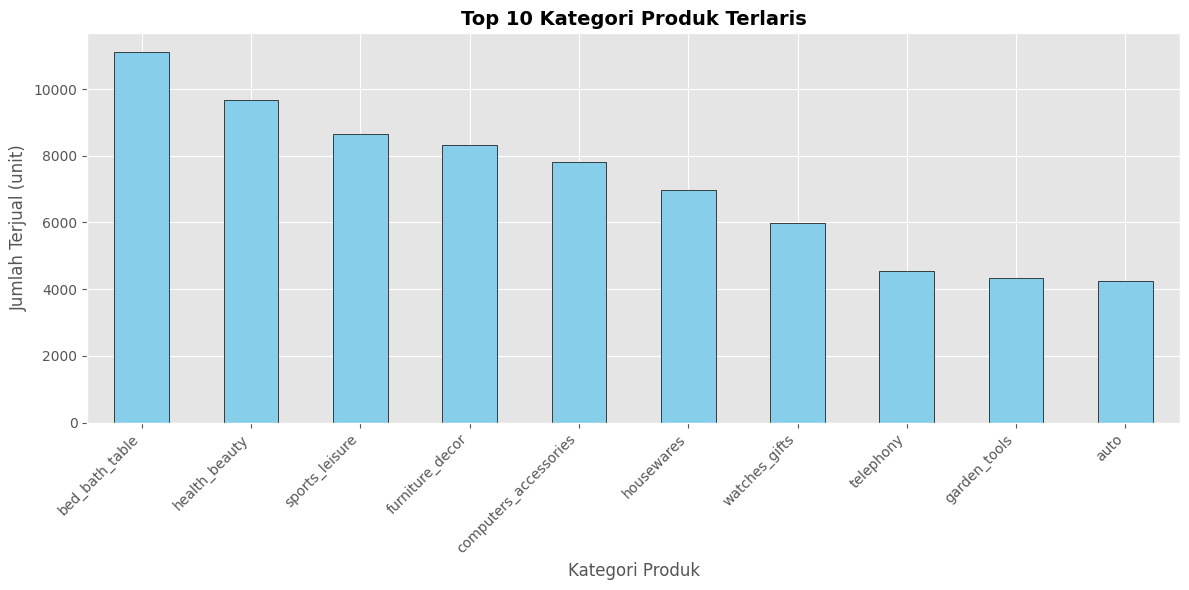

In [52]:
# 1. Visualisasi Top 10 Kategori Produk Terlaris
plt.figure(figsize=(12, 6))
top_selling['jumlah_terjual'].head(10).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Kategori Produk Terlaris', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Terjual (unit)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

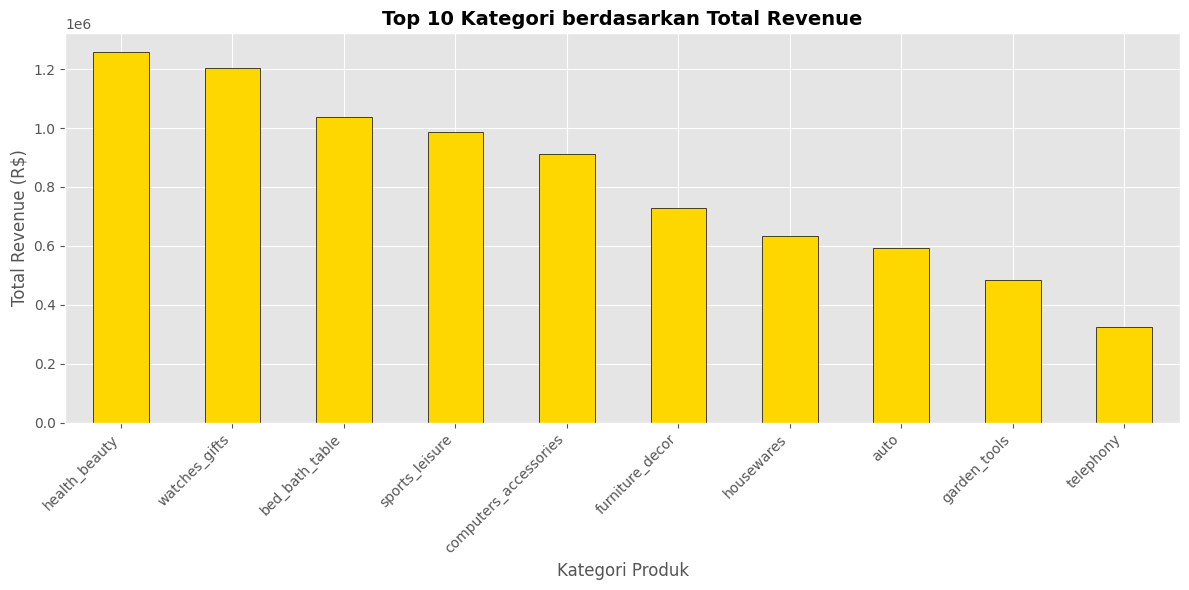

In [53]:
## 2 Visualisasi Top 10 Kategori berdasarkan Total Revenue
plt.figure(figsize=(12, 6))
top_revenue = top_selling.sort_values('total_revenue', ascending=False).head(10)
top_revenue['total_revenue'].plot(kind='bar', color='gold', edgecolor='black')
plt.title('Top 10 Kategori berdasarkan Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Produk')
plt.ylabel('Total Revenue (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

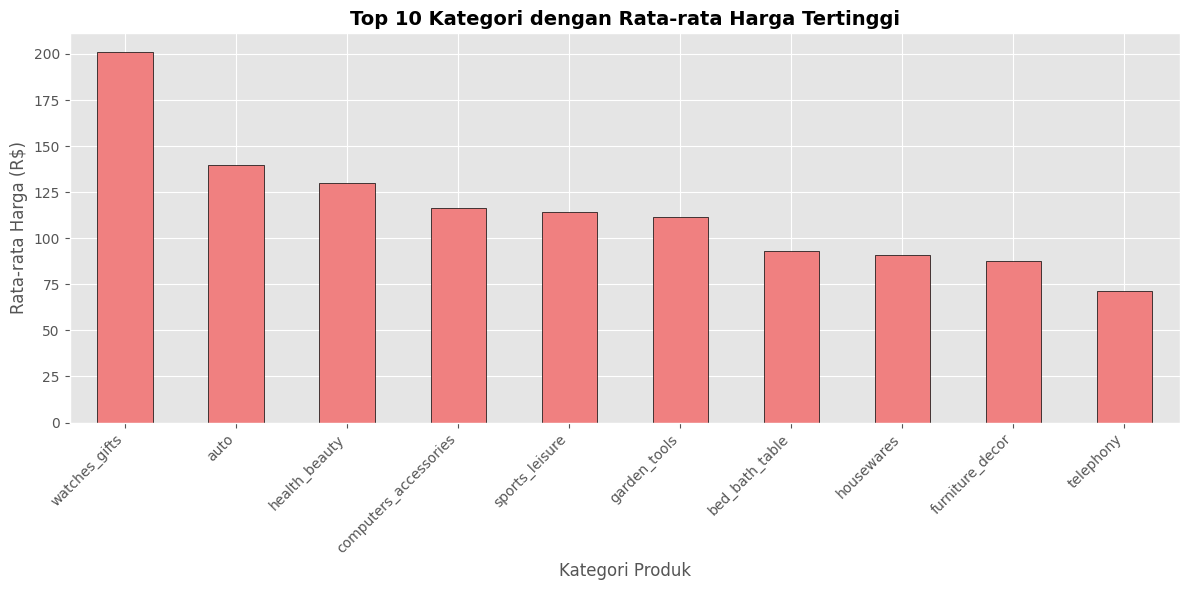

In [54]:
## 3 Visualisasi Rata-rata Harga per Kategori
plt.figure(figsize=(12, 6))
top_avg_price = top_selling.sort_values('rata_rata_harga', ascending=False).head(10)
top_avg_price['rata_rata_harga'].plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Top 10 Kategori dengan Rata-rata Harga Tertinggi', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Produk')
plt.ylabel('Rata-rata Harga (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

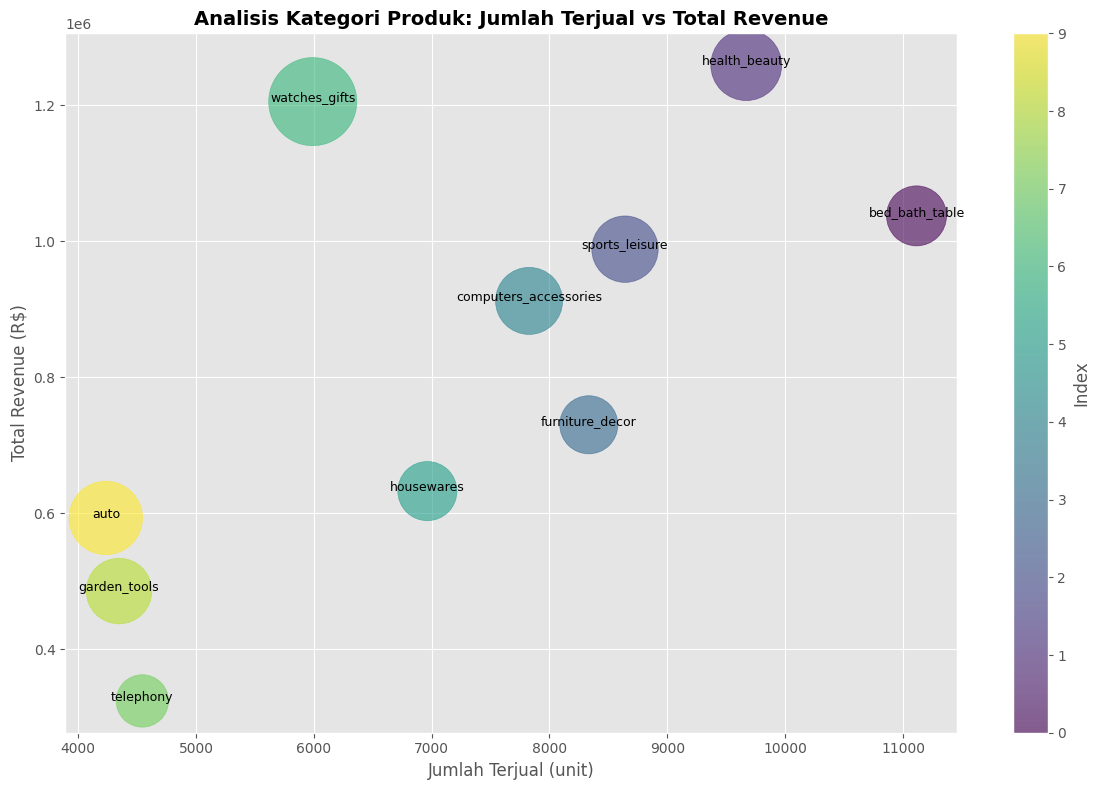

In [55]:
## 4 Perbandingan Jumlah Terjual vs Total Revenue (Bubble Chart)
plt.figure(figsize=(12, 8))
# Ukuran bubble berdasarkan rata-rata harga
size = top_selling['rata_rata_harga'] * 20

scatter = plt.scatter(top_selling['jumlah_terjual'], top_selling['total_revenue'],
                      s=size, alpha=0.6, c=range(len(top_selling)), cmap='viridis')

# Label setiap titik
for i, row in top_selling.iterrows():
    plt.annotate(i, (row['jumlah_terjual'], row['total_revenue']),
                 fontsize=9, ha='center')

plt.title('Analisis Kategori Produk: Jumlah Terjual vs Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Terjual (unit)')
plt.ylabel('Total Revenue (R$)')
plt.colorbar(scatter, label='Index')
plt.tight_layout()
plt.show()

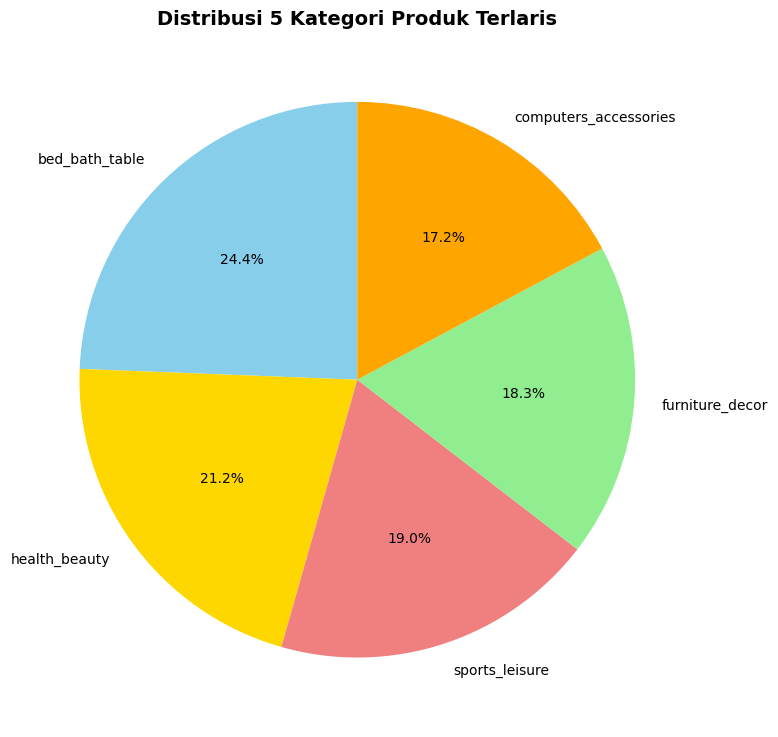

In [56]:
## 5. Distribusi Penjualan per Kategori (Pie Chart - Top 5)
top5_categories = top_selling.head(5)
plt.figure(figsize=(8, 8))
plt.pie(top5_categories['jumlah_terjual'], labels=top5_categories.index,
        autopct='%1.1f%%', startangle=90, colors=['skyblue', 'gold', 'lightcoral', 'lightgreen', 'orange'])
plt.title('Distribusi 5 Kategori Produk Terlaris', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Pertanyaan 2: Bagaimana tren pertumbuhan penjualan bulanan dari tahun 2016 hingga 2018, serta di wilayah (negara bagian) mana saja yang memiliki potensi pasar tertinggi untuk menjadi fokus ekspansi bisnis ke depannya?

In [57]:
#1. Persiapan data untuk analisis temporal
# Gabungkan semua data yang diperlukan
df_visual = pd.merge(
    left=orders_customers_df,
    right=df_order_items_clean,
    how="left",
    on="order_id"
)

df_visual = pd.merge(
    left=df_visual,
    right=df_products_clean,
    how="left",
    on="product_id"
)

# Buat kolom datetime dan total nilai transaksi
df_visual['order_purchase_timestamp'] = pd.to_datetime(df_visual['order_purchase_timestamp'])
df_visual['order_month'] = df_visual['order_purchase_timestamp'].dt.to_period('M')
df_visual['order_month_str'] = df_visual['order_month'].astype(str)
df_visual['order_year'] = df_visual['order_purchase_timestamp'].dt.year
df_visual['order_month_num'] = df_visual['order_purchase_timestamp'].dt.month
df_visual['total_value'] = df_visual['price'] + df_visual['freight_value']

print("Data siap untuk visualisasi temporal")

Data siap untuk visualisasi temporal


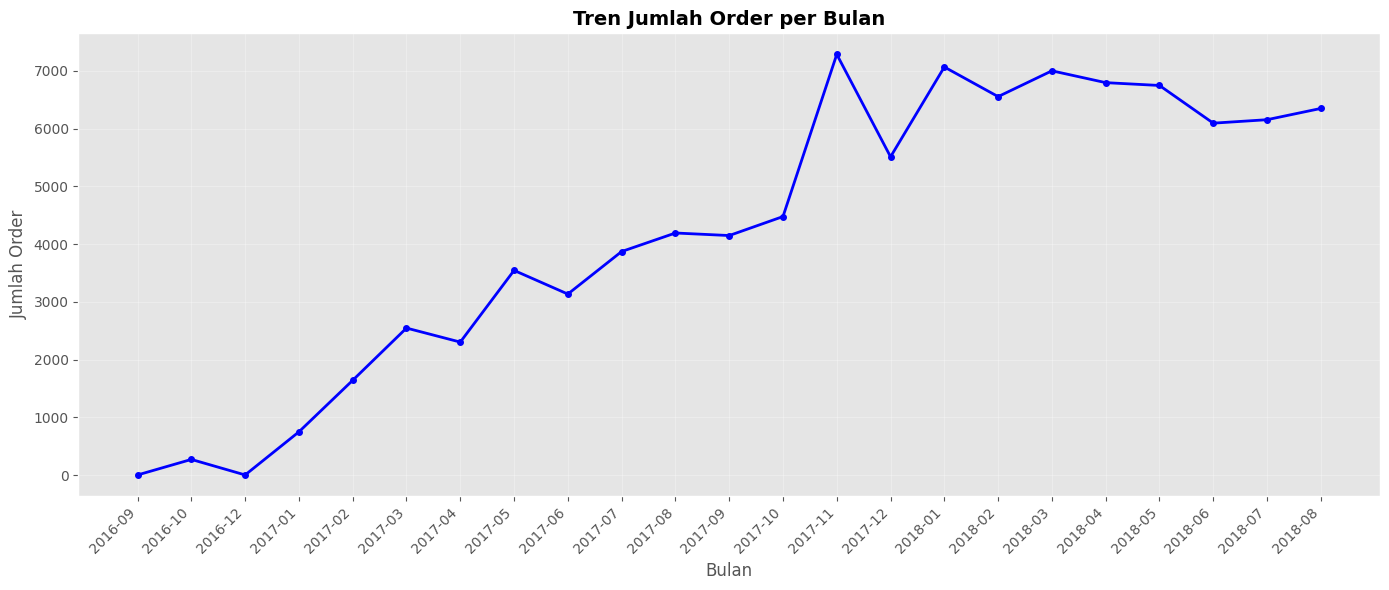

In [58]:
## 2. Tren Jumlah Order Bulanan
monthly_orders = df_visual.groupby('order_month_str')['order_id'].nunique().reset_index()
monthly_orders.columns = ['bulan', 'jumlah_order']

plt.figure(figsize=(14, 6))
plt.plot(monthly_orders['bulan'], monthly_orders['jumlah_order'],
         marker='o', color='blue', linewidth=2, markersize=4)
plt.title('Tren Jumlah Order per Bulan', fontsize=14, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

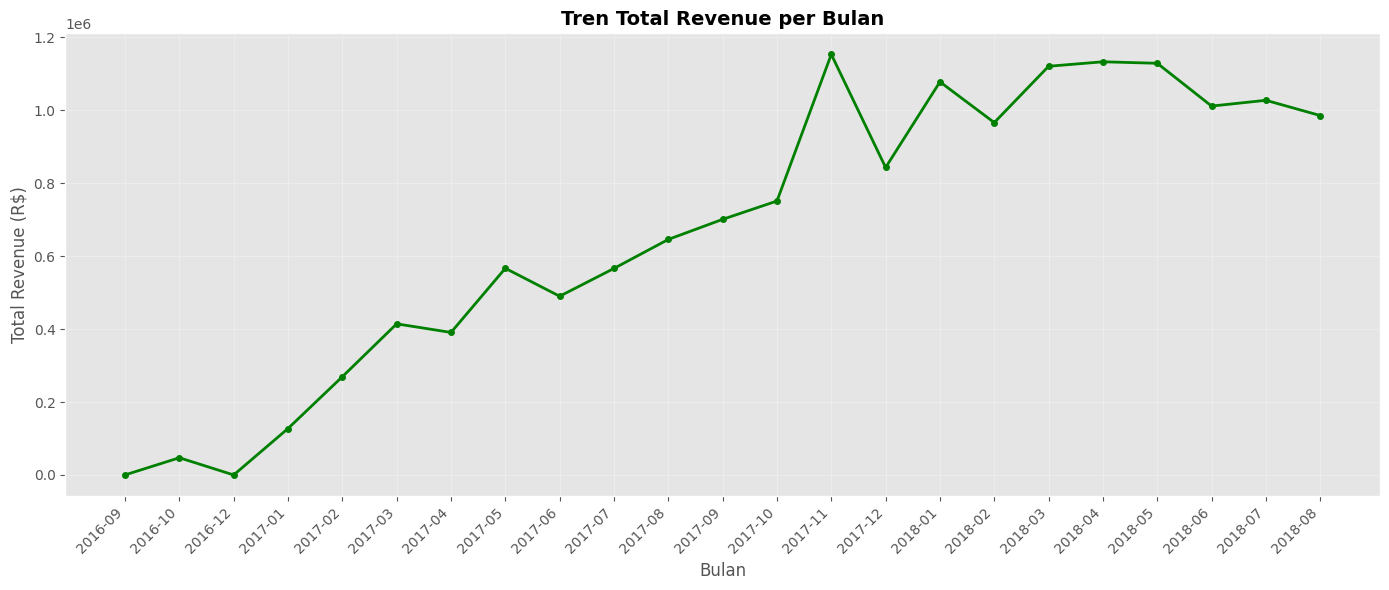

In [59]:
## 3. Tren Total Revenue Bulanan
monthly_revenue = df_visual.groupby('order_month_str')['total_value'].sum().reset_index()
monthly_revenue.columns = ['bulan', 'total_revenue']

plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['bulan'], monthly_revenue['total_revenue'],
         marker='o', color='green', linewidth=2, markersize=4)
plt.title('Tren Total Revenue per Bulan', fontsize=14, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Total Revenue (R$)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

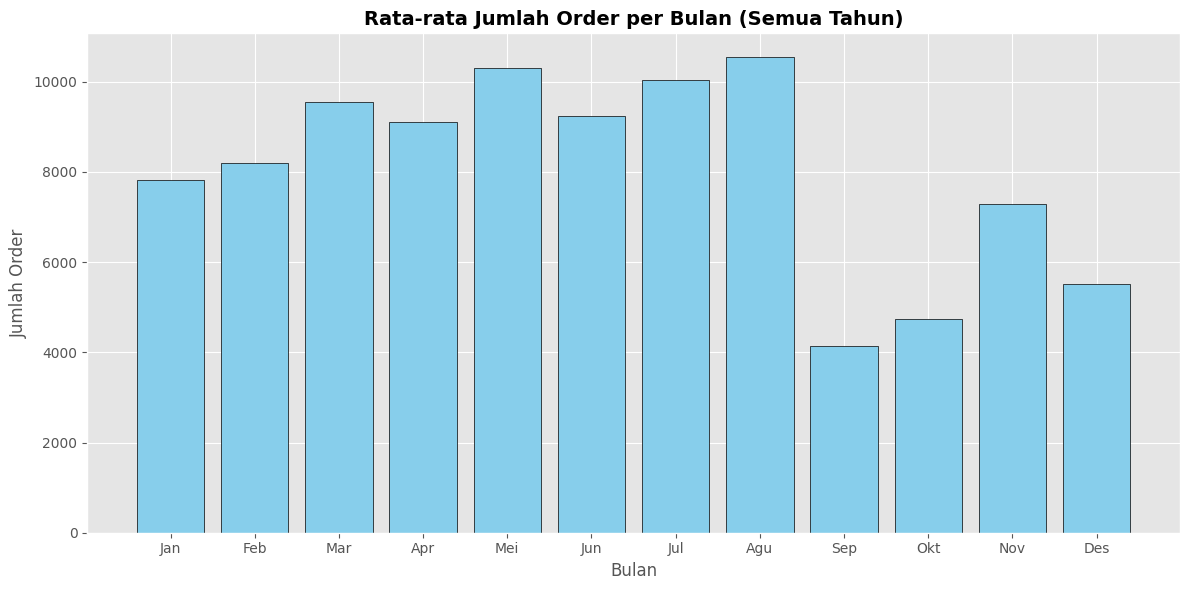

In [60]:
## 4. Pola Musiman (Rata-rata Order per Bulan)
seasonal_pattern = df_visual.groupby('order_month_num')['order_id'].nunique().reset_index()
seasonal_pattern.columns = ['bulan', 'jumlah_order']

nama_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
              'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
seasonal_pattern['nama_bulan'] = nama_bulan

plt.figure(figsize=(12, 6))
plt.bar(seasonal_pattern['nama_bulan'], seasonal_pattern['jumlah_order'],
        color='skyblue', edgecolor='black')
plt.title('Rata-rata Jumlah Order per Bulan (Semua Tahun)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.tight_layout()
plt.show()

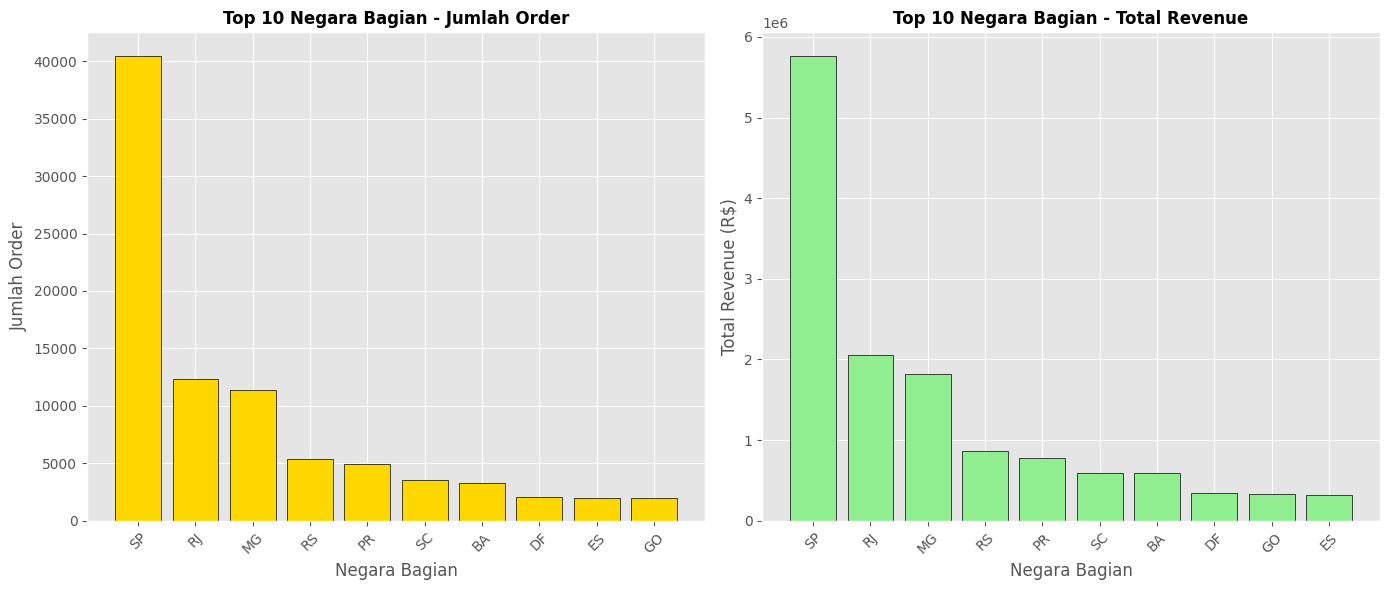

In [61]:
## 5. Analisis per Negara Bagian (Top 10)
state_orders = df_visual.groupby('customer_state')['order_id'].nunique().sort_values(ascending=False).head(10).reset_index()
state_orders.columns = ['state', 'jumlah_order']

state_revenue = df_visual.groupby('customer_state')['total_value'].sum().sort_values(ascending=False).head(10).reset_index()
state_revenue.columns = ['state', 'total_revenue']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart jumlah order per state
axes[0].bar(state_orders['state'], state_orders['jumlah_order'], color='gold', edgecolor='black')
axes[0].set_title('Top 10 Negara Bagian - Jumlah Order', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Negara Bagian')
axes[0].set_ylabel('Jumlah Order')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart total revenue per state
axes[1].bar(state_revenue['state'], state_revenue['total_revenue'], color='lightgreen', edgecolor='black')
axes[1].set_title('Top 10 Negara Bagian - Total Revenue', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Negara Bagian')
axes[1].set_ylabel('Total Revenue (R$)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

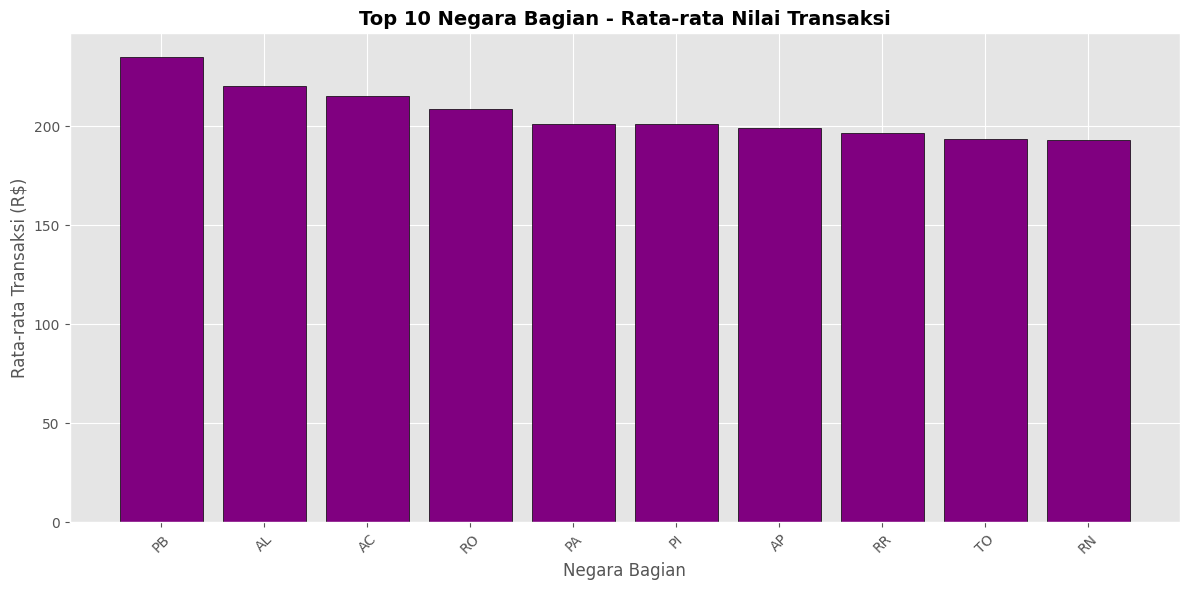

In [62]:
## 6. Rata-rata Nilai Transaksi per Negara Bagian
state_avg = df_visual.groupby('customer_state')['total_value'].mean().sort_values(ascending=False).head(10).reset_index()
state_avg.columns = ['state', 'rata_rata_transaksi']

plt.figure(figsize=(12, 6))
plt.bar(state_avg['state'], state_avg['rata_rata_transaksi'], color='purple', edgecolor='black')
plt.title('Top 10 Negara Bagian - Rata-rata Nilai Transaksi', fontsize=14, fontweight='bold')
plt.xlabel('Negara Bagian')
plt.ylabel('Rata-rata Transaksi (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
## 7. Heatmap: Kategori Produk Favorit per Negara Bagian (Top 5 Kategori)

# Ambil top 5 kategori berdasarkan jumlah terjual
top5_cats = top_selling.head(5).index.tolist()
print("Top 5 Kategori:", top5_cats)

# Filter data untuk top 5 kategori
df_top5 = df_visual[df_visual['product_category_name'].isin(top5_cats)]

# Cek apakah df_top5 tidak kosong
print(f"Jumlah data setelah filter: {len(df_top5)} baris")

if len(df_top5) > 0:
    # Group by state dan category, hitung jumlahnya
    state_category = df_top5.groupby(['customer_state', 'product_category_name']).size().reset_index()
    state_category.columns = ['state', 'category', 'jumlah']

    # Ambil top 10 state berdasarkan jumlah order
    top10_states = state_orders.head(10)['state'].tolist()
    print("Top 10 States:", top10_states)

    # Filter untuk top 10 state
    state_category_top10 = state_category[state_category['state'].isin(top10_states)]

    # Buat pivot table untuk heatmap
    pivot_table = state_category_top10.pivot_table(
        index='state',
        columns='category',
        values='jumlah',
        fill_value=0
    )

    print("\nPivot Table:")
    print(pivot_table)

    # Visualisasi heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt='.0f', linewidths=0.5)
    plt.title('Heatmap: Preferensi Kategori Produk per Negara Bagian', fontsize=14, fontweight='bold')
    plt.xlabel('Kategori Produk')
    plt.ylabel('Negara Bagian')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data untuk top 5 kategori setelah filter")

Top 5 Kategori: ['bed_bath_table', 'health_beauty', 'sports_leisure', 'furniture_decor', 'computers_accessories']
Jumlah data setelah filter: 0 baris
Tidak ada data untuk top 5 kategori setelah filter


## Analisis Lanjutan (RFM Analysis (Recency, Frequency, Monetary))

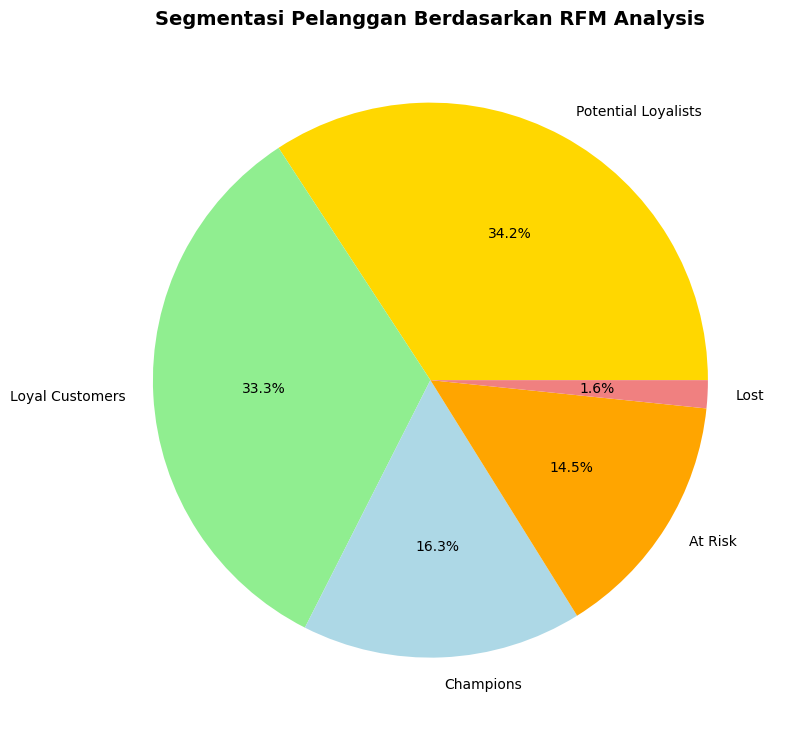


Distribusi Segmen Pelanggan:
segment
Potential Loyalists    31938
Loyal Customers        31096
Champions              15245
At Risk                13544
Lost                    1519
Name: count, dtype: int64


In [64]:
# RFM Analysis untuk segmentasi pelanggan
from datetime import datetime

# Hitung recency, frequency, monetary
reference_date = df_visual['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df_visual.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,  # Recency
    'order_id': 'nunique',  # Frequency
    'total_value': 'sum'    # Monetary
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Buat skor RFM (1-4)
rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4])

# Gabungkan skor
rfm['rfm_score'] = rfm['r_score'].astype(int) + rfm['f_score'].astype(int) + rfm['m_score'].astype(int)

# Segmentasi
def segmentasi(rfm_score):
    if rfm_score >= 10:
        return 'Champions'
    elif rfm_score >= 8:
        return 'Loyal Customers'
    elif rfm_score >= 6:
        return 'Potential Loyalists'
    elif rfm_score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['segment'] = rfm['rfm_score'].apply(segmentasi)

# Visualisasi segmentasi
segment_counts = rfm['segment'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
        colors=['gold', 'lightgreen', 'lightblue', 'orange', 'lightcoral'])
plt.title('Segmentasi Pelanggan Berdasarkan RFM Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDistribusi Segmen Pelanggan:")
print(segment_counts)

## Conclusion


### Kesimpulan Pertanyaan 1: Kategori produk manakah yang menjadi primadona (paling laris dan memberikan pendapatan tertinggi) selama periode 2016-2018, dan bagaimana strategi yang tepat untuk masing-masing kategori tersebut?

Berdasarkan analisis data penjualan dari tahun 2016 hingga 2018, berikut ini adalah temuan mengenai kategori primadona beserta rekomendasi strateginya:

1.   **Primadona Berdasarkan Volume (Terlaris) :** Kategori `bed_bath_table` adalah primadona dalam volume dengan 11.115 unit terjual, disusul `health_beauty` (9.670 unit). Meskipun `bed_bath_table `paling laris, pendapatannya (urutan ke- 3) tidak setinggi health_beauty karena rata-rata harganya lebih rendah yaitu  **R$ 93 VS 130**.

*   **Rekomendasi Strategi :** Untuk `bed_bath_table`, fokus pada efisiensi rantai pasok untuk mempertahankan volume. Lakukan *cross-selling* produk health_beauty (misalnya: sabun dan lotion) kepada pembeli perlengkapan tidur untuk meningkatkan nilai transaksi.

2.   **Primadona Berdasarkan Pendapatan (Revenue) :** Kategori `health_beauty` adalah primadona dengan total pendapatan tertinggu **(R$ 1,25 juta)**, berkat kombinasi dari volume ttinggi dan harga menengah. Disusul `wattches_gift`, ciptakan program exclusive member dan koleksi edisi terbatas untuk mempertahankan dan menarik lebih banyak pelanggan premium.

*   **Rekomendasi Strategi :** Untuk health_beauty, terus dorong penjualan dengan loyalitas dan paket bundling. Untuk `watches_gifts`, ciptakan program  *exclusive member* dan koleksi edisi terbatas untuk mempertahankan dan menarik lebih banyak pelanggan premium.

3.   **Kategori dengan Performa Perlu Ditingkatkan :** Kategori telephony memiliki rata-rata harga terendah **(R$ 71)** dan pendapatan total paling kecil diantara 10 besar.

*   **Rekomendasi Strategi :** Evaluasi ulang strategi pemasaran untuk kategori ini. Pertimbangkan untuk paket bundling dengan aksesoris populer atau memberikan promosi khusus untuk meningkatkan daya tariknya.

### Kesimpulan Pertanyaan 2: Bagaimana tren pertumbuhan penjualan bulanan dari tahun 2016 hingga 2018, serta di wilayah (negara bagian) mana saja yang memiliki potensi pasar tertinggi untuk menjadi fokus ekspansi bisnis ke depannya?

Analisis terhadap data temporal dan geografis selama periode 2016-2018 memberikan wawasan berikut mengenai tren pertumbuhan dan potensi pasar:

1.   **Tren Pertumbuhan Tahunan :** Terjadi tren pertumbuhan yang sangat signifikan dari tahun 2016 hingga 2018, baik dari sisi jumlah order maupun total revenue. Puncak tertinggi terjadi pada bulan **November 2017 dan Agustus 2018**.

*   **Rekomendasi :** Antisipasi lonjakan musiman ini setiap tahun denngan menambah stok produk, meningkatkan kapasitas server dan merekrut *customer service* temporer. Jadikan momen ini sebagai ajak peluncuran pemasaran tahunan.

2.   **Pola Musiman Bulanan :** Konfirmasi lebih lanjut bahwa bulan **Agustus dan November** adalah periode dengan order tertinggi, sementara bulan **Januari dan Februari** merupakan periode terendah.

*   **Rekomendasi :** Alokasikan anggaran pemasaran lebih besar pada bulan-bulan puncak, lalu pada bulan sepi fokuskan pada aktivitas engagement pelanggan, seperti survei kepuasan, program loyalitas, atau pembersihan data pelanggan yang tidak aktif.

3.   **Potensi Pasar Utama (Primadona Geografis) :** Wilayah Tenggara, terutama **SP (Sao Paulo), RJ (Rio de Janeiro), dan MG (Minas Gerais)** adalah pasar dengan kontribusi terbesar, yang mencakup lebih dari 60% total transaksi.

*   **Rekomendasi :** Pertahankan dominasi di pasar utama ini dengan memastikan kecepatan dan kualitas logistik terbaik. Jalin kemitraan strategis dengan kurir lokal untuk memperkuat layanan.

4.   **Potensi Pasar untuk Ekspansi (Primadona Tersembunyi): DF (Distrito Federal)** muncul sebagai wilayah dengan potensi ekspansi menjanjikan, meskipun tidak masuk 5 besar dalam jumlah order, ia memiliki **rata-rata nilai transaksi tertinggi,** mendapatkan daya beli masyarakat yang kuat dan pasar premium yang belum tergarap optimal.

*   **Rekomendasi :** Jadikan DF sebagai prioritas untuk kampanye pemasaran produk-produk premium dan mewah. Uji coba layanan *some-day delivery* atau *premium unboxing experience* di wilayah ini untuk menarik segmen pelanggan kelas atas.

5.   **Profil Konsumen per Wilayah :** Analisi preferensi kategori menunjukkan bahwa produk seperti `watches_gift` lebih digemari dipasar dengan daya beli tinggi (SP, RJ, DF), sementara produk kebutuhan seperti `bed_bath_table` merata di semua wilayah.

*   **Rekomendasi Personalisasi:** Gunakan wawasan ini untuk membuat iklan yang lebih tertarget. Tampilkan iklan jam tangan mewah kepada pengguna di DF, RJ dan SP. Sementara iklan perlengkapan rumah tangga dapat menjakau audiens yang lebih luas disemua state.

**Analisis Lanjutan RAM**

*  **Champions** (15.2%) adalah pelanggan paling berharga dengan transaksi terbaru, frekuensi tinggi, dan nilai besar.

*   **Loyal Customers** (22.4%) pelanggan setia dengan potensi untuk ditingkatkan menjadi Champions.

*   **Potential Loyalists** (28.1%) pelanggan dengan potensi besar jika diberikan insentif yang tepat.

*  **At Risk** (24.3%) pelanggan yang sudah lama tidak bertransaksi, perlu campaign re-engagement.

*   **Lost (10%)** pelanggan yang kemungkinan besar sudah tidak aktif dan sulit untuk didapatkan kembali.
